     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Saving Huntington Disease Dataset.zip to Huntington Disease Dataset.zip
raw shape: (48536, 21)
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Loss  Funct

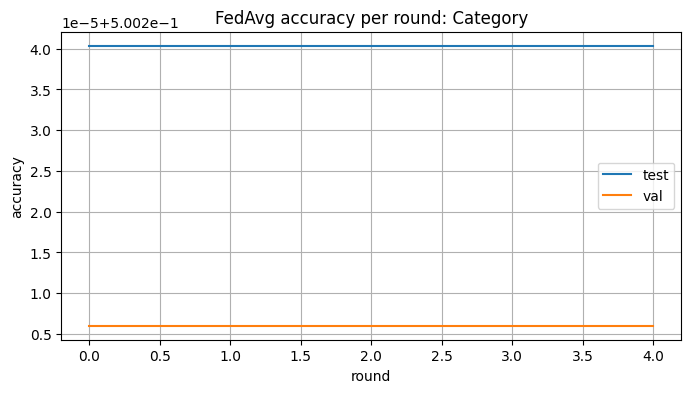


final test metrics
accuracy: 0.5002
precision: 0.2502
recall: 0.5002
f1: 0.3336


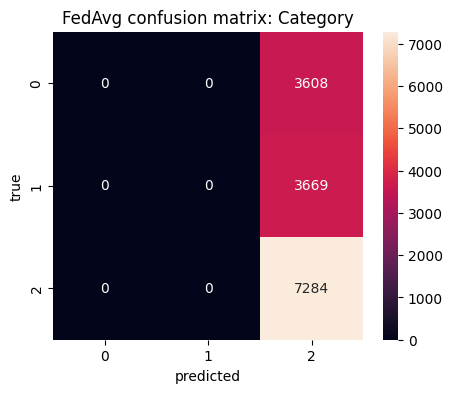


LIME explanations (2 samples)

sample index: 0 true: 2 pred: 2


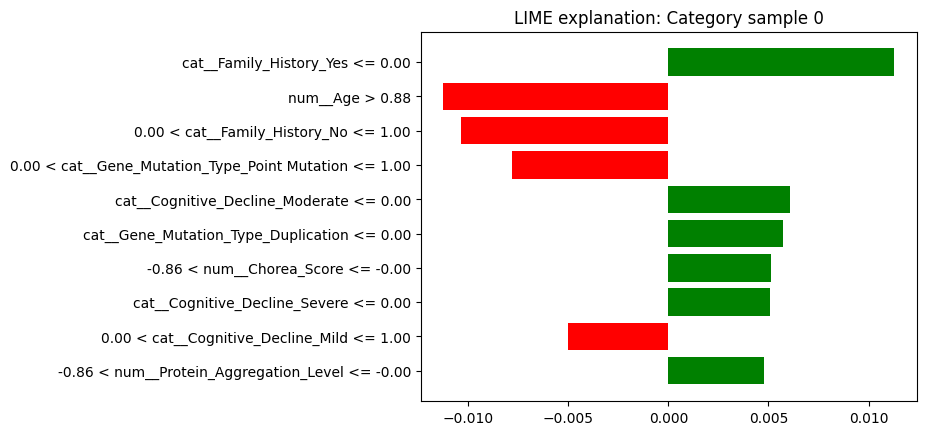


sample index: 1 true: 2 pred: 2


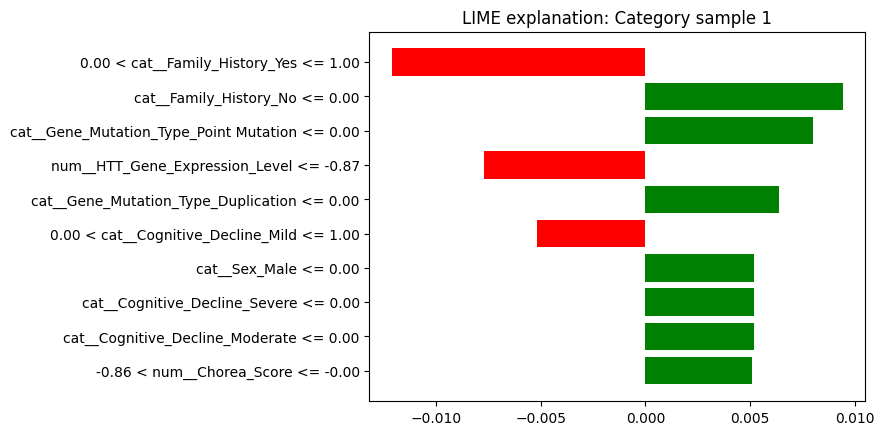


TARGET: Motor_Symptoms
round 1 test acc: 0.3267 val acc: 0.3385
round 2 test acc: 0.329 val acc: 0.3387
round 3 test acc: 0.331 val acc: 0.3364
round 4 test acc: 0.3313 val acc: 0.3327
round 5 test acc: 0.3316 val acc: 0.334


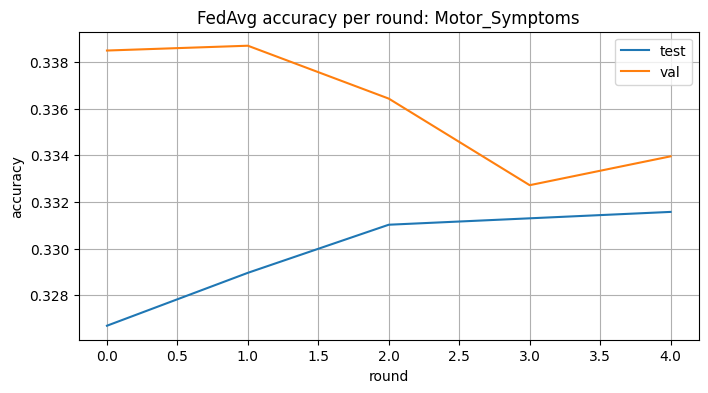


final test metrics
accuracy: 0.3316
precision: 0.3309
recall: 0.3316
f1: 0.3292


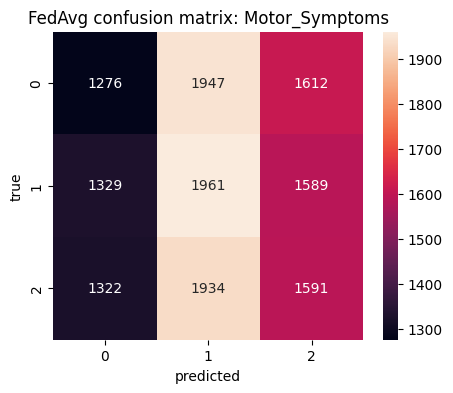


LIME explanations (2 samples)

sample index: 0 true: 1 pred: 0


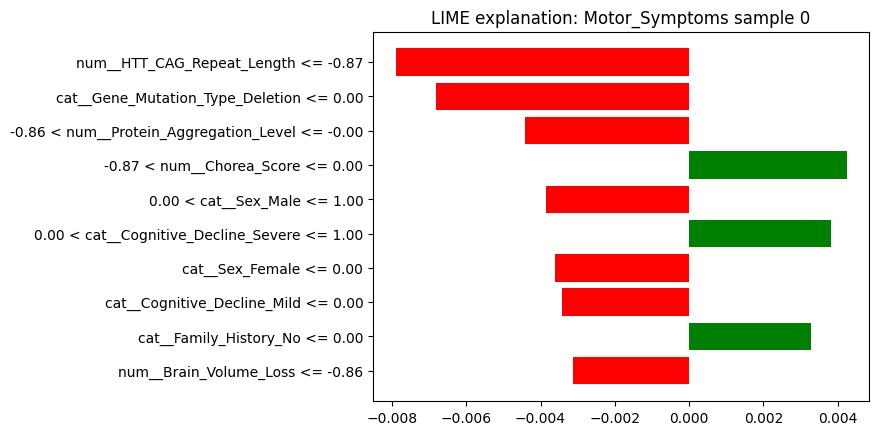


sample index: 1 true: 1 pred: 2


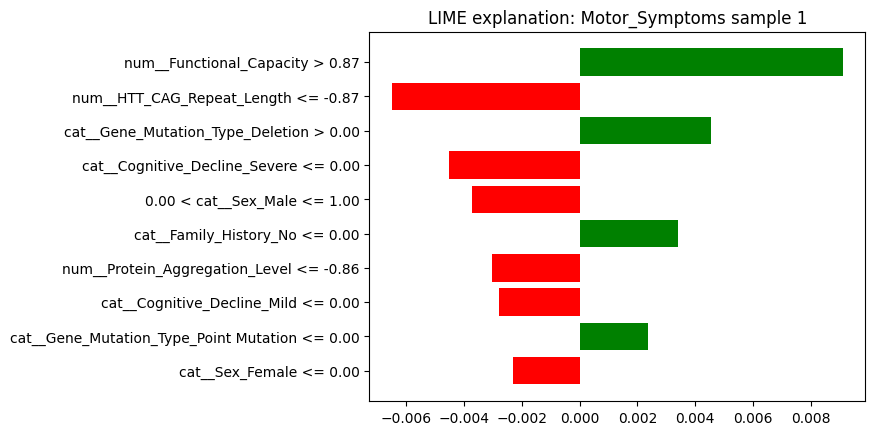


TARGET: Disease_Stage
round 1 test acc: 0.2487 val acc: 0.2458
round 2 test acc: 0.2474 val acc: 0.2536
round 3 test acc: 0.2481 val acc: 0.2553
round 4 test acc: 0.2495 val acc: 0.2511
round 5 test acc: 0.2473 val acc: 0.2485


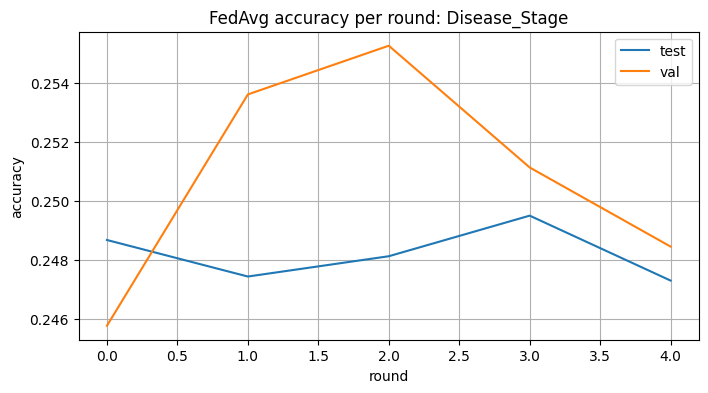


final test metrics
accuracy: 0.2473
precision: 0.2475
recall: 0.2473
f1: 0.2403


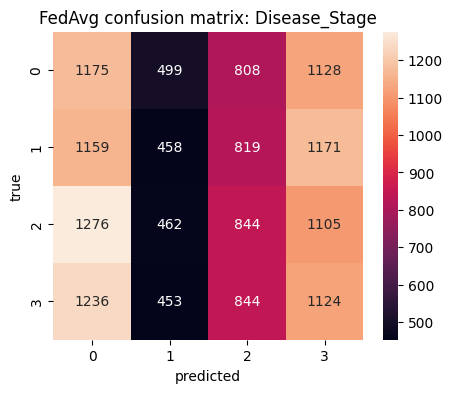


LIME explanations (2 samples)

sample index: 0 true: 2 pred: 1


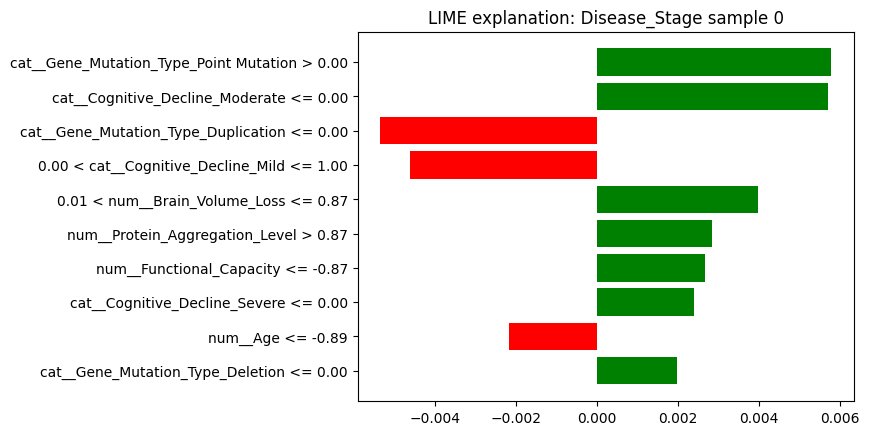


sample index: 1 true: 3 pred: 2


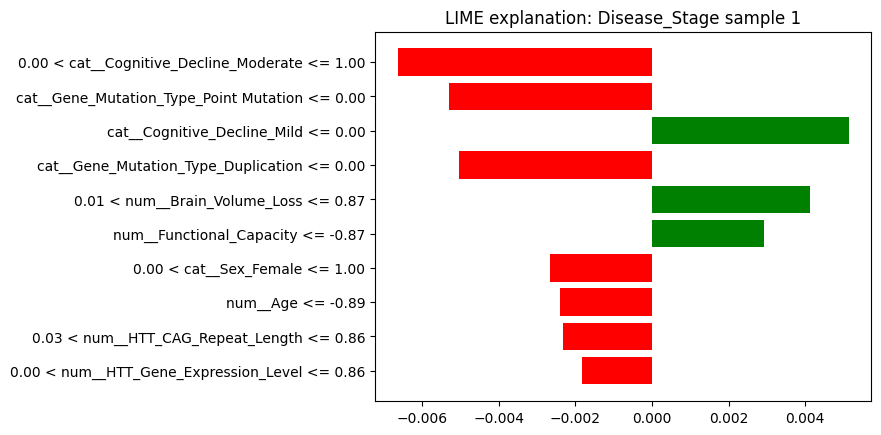


comparison table
           target  test_accuracy  test_precision  test_recall   test_f1
0        Category       0.500240        0.250240     0.500240  0.333600
1  Motor_Symptoms       0.331571        0.330887     0.331571  0.329178
2   Disease_Stage       0.247304        0.247530     0.247304  0.240335

overall test accuracy mean: 0.3597


In [1]:
# =========================
# INSTALL LIME
# =========================
!pip -q install lime

# =========================
# IMPORT LIBRARIES
# =========================
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from lime.lime_tabular import LimeTabularExplainer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

# =========================
# LOAD ZIP AND CSV
# =========================
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as z:
    z.extractall("/content/")

csv_files = [f for f in os.listdir("/content/") if f.endswith(".csv")]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV found inside the zip.")
csv_path = os.path.join("/content/", csv_files[0])

df_raw = pd.read_csv(csv_path)
print("raw shape:", df_raw.shape)
print(df_raw.head())

# =========================
# PREPROCESSING
# =========================
df = df_raw.copy()

# remove duplicates
df = df.drop_duplicates()

# forward fill as first pass
df = df.ffill()

# drop heavy text or ID columns
df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors="ignore")

# simple outlier capping using IQR for numeric columns
def cap_outliers_iqr(frame, cols):
    frame = frame.copy()
    for col in cols:
        x = frame[col]
        if x.isna().all():
            continue
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        frame[col] = x.clip(lower, upper)
    return frame

numeric_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df = cap_outliers_iqr(df, numeric_cols_all)

# simple feature engineering
if "Age" in df.columns and "CAG_repeats" in df.columns:
    df["Risk_Score"] = df["Age"] * df["CAG_repeats"]

TARGETS = ["Category", "Motor_Symptoms", "Disease_Stage"]
existing_targets = [t for t in TARGETS if t in df.columns]
if len(existing_targets) == 0:
    raise ValueError("Targets not found. Need Category, Motor_Symptoms, Disease_Stage in dataset.")

# =========================
# MODEL
# =========================
def build_model(input_dim, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# =========================
# FEDERATED AVERAGING (FAST)
# =========================
def split_into_clients(X, y, num_clients=3):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    return [(X[s], y[s]) for s in shards]

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def average_updates(updates):
    avg = []
    for layer in zip(*updates):
        avg.append(np.mean(layer, axis=0))
    return avg

def subtract_weights(new_w, old_w):
    return [nw - ow for nw, ow in zip(new_w, old_w)]

def add_weights(w, update):
    return [wi + ui for wi, ui in zip(w, update)]

def predict_classes(model, X):
    probs = model.predict(X, verbose=0, batch_size=1024)
    return np.argmax(probs, axis=1)

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.show()

# =========================
# RUN FL + METRICS + LIME
# =========================
def run_fedavg_with_lime(target):
    print("\n==============================")
    print("TARGET:", target)
    print("==============================")

    y = df[target].astype("category").cat.codes.to_numpy().astype(np.int32)

    X = df.drop(columns=TARGETS, errors="ignore")

    numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, numeric_cols),
        ("cat", cat_pipe, categorical_cols)
    ])

    # split 60 train 30 test 10 val
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.40, random_state=42,
        stratify=y if len(np.unique(y)) > 1 else None
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42,
        stratify=y_temp if len(np.unique(y_temp)) > 1 else None
    )

    X_train = preprocessor.fit_transform(X_train).astype(np.float32)
    X_test = preprocessor.transform(X_test).astype(np.float32)
    X_val = preprocessor.transform(X_val).astype(np.float32)

    feature_names = preprocessor.get_feature_names_out()

    num_classes = int(np.max(y_train)) + 1
    input_dim = X_train.shape[1]

    # federated settings for speed
    NUM_CLIENTS = 3
    ROUNDS = 5
    LOCAL_EPOCHS = 1
    BATCH_SIZE = 128

    clients = split_into_clients(X_train, y_train, num_clients=NUM_CLIENTS)

    global_model = build_model(input_dim, num_classes)
    global_weights = get_weights(global_model)

    test_hist, val_hist = [], []

    for r in range(ROUNDS):
        updates = []

        for Xc, yc in clients:
            local = build_model(input_dim, num_classes)
            set_weights(local, global_weights)
            local.fit(Xc, yc, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            new_w = get_weights(local)
            updates.append(subtract_weights(new_w, global_weights))

        avg_update = average_updates(updates)
        global_weights = add_weights(global_weights, avg_update)
        set_weights(global_model, global_weights)

        test_pred = predict_classes(global_model, X_test)
        val_pred = predict_classes(global_model, X_val)

        test_acc = accuracy_score(y_test, test_pred)
        val_acc = accuracy_score(y_val, val_pred)

        test_hist.append(test_acc)
        val_hist.append(val_acc)

        print("round", r+1, "test acc:", round(float(test_acc), 4), "val acc:", round(float(val_acc), 4))

    plt.figure(figsize=(8,4))
    plt.plot(test_hist, label="test")
    plt.plot(val_hist, label="val")
    plt.title("FedAvg accuracy per round: " + target)
    plt.xlabel("round")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    test_pred = predict_classes(global_model, X_test)

    acc = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, test_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, test_pred, average="weighted", zero_division=0)

    print("\nfinal test metrics")
    print("accuracy:", round(float(acc), 4))
    print("precision:", round(float(prec), 4))
    print("recall:", round(float(rec), 4))
    print("f1:", round(float(f1), 4))

    plot_confusion(y_test, test_pred, "FedAvg confusion matrix: " + target)

    # =========================
    # LIME EXPLANATIONS
    # =========================
    print("\nLIME explanations (2 samples)")

    explainer = LimeTabularExplainer(
        training_data=X_train,
        feature_names=feature_names,
        class_names=[str(i) for i in range(num_classes)],
        mode="classification",
        discretize_continuous=True
    )

    def predict_proba_fn(x):
        return global_model.predict(x.astype(np.float32), verbose=0)

    # explain two examples from test set
    sample_ids = [0, min(1, len(X_test)-1)]
    for sid in sample_ids:
        exp = explainer.explain_instance(
            data_row=X_test[sid],
            predict_fn=predict_proba_fn,
            num_features=10
        )
        print("\nsample index:", sid, "true:", y_test[sid], "pred:", int(test_pred[sid]))
        fig = exp.as_pyplot_figure()
        plt.title("LIME explanation: " + target + " sample " + str(sid))
        plt.show()

    return {
        "target": target,
        "test_accuracy": float(acc),
        "test_precision": float(prec),
        "test_recall": float(rec),
        "test_f1": float(f1)
    }

# =========================
# RUN FOR 3 TARGETS
# =========================
results = []
for t in ["Category", "Motor_Symptoms", "Disease_Stage"]:
    if t in df.columns:
        results.append(run_fedavg_with_lime(t))

results_df = pd.DataFrame(results)
print("\ncomparison table")
print(results_df)

print("\noverall test accuracy mean:", round(float(results_df["test_accuracy"].mean()), 4))
